# 03 - Baseline: ECFP4 + ESM pocket-pool + XGBoost

ECFP4 (2048 bits) + ESM-2 pocket/whole-protein embeddings (480 + 480) -> XGBoost. Trained on refined minus CASF-2016, 90/10 train/val, tested on CASF-2016 core set.

Literature reference (similar features): Pearson R ~0.77, RMSE ~1.40 (Su et al. 2019).

In [1]:
from __future__ import annotations

import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tqdm.auto import tqdm

from plb.data import (
    DEFAULT_ESM_MODEL,
    ecfp_from_sdf,
    find_default_paths,
    load_esm_embedding_matrix,
    load_refined_index,
)

DATA_ROOT = Path("../data")
PROCESSED = DATA_ROOT / "processed"
REPORTS = Path("../reports")
REPORTS.mkdir(parents=True, exist_ok=True)

print("Data root:", DATA_ROOT.resolve())

Data root: C:\Users\fearg\Protein_Ligand_Binding\data


## Load split + labels

Split from `plb data prepare` — test set = CASF-2016 ∩ refined index (266 complexes), no leakage.

In [2]:
paths = find_default_paths(DATA_ROOT)
df = load_refined_index(paths["refined_index"]).set_index("pdb_id")
split = json.loads((PROCESSED / "split.json").read_text())

for k in ("train", "val", "test"):
    print(f"{k}: {len(split[k]):>5d} complexes")
df.head(3)

train:  4545 complexes
val:   505 complexes
test:   266 complexes


,resolution,release_year,pK,affinity_raw,ligand_name
pdb_id,,,,,
10gs,2.2,1998,6.40,Ki=0.4uM,VWW
184l,1.8,1995,4.72,Kd=19uM,I4B
185l,1.8,1995,3.54,Kd=290uM,IND


## Build feature matrices

ECFP4 + ESM embeddings per complex, cached to `data/processed/baseline_features.npz`.

In [3]:
FEATURES_PATH = PROCESSED / "baseline_features.npz"
REFINED_ROOT = paths["refined_root"]
ALL_IDS = sorted(set(split["train"]) | set(split["val"]) | set(split["test"]))
print(f"Total complexes to featurise: {len(ALL_IDS)}")


def build_feature_cache() -> dict[str, np.ndarray]:
    X_esm, kept = load_esm_embedding_matrix(
        ALL_IDS, data_root=DATA_ROOT, model_name=DEFAULT_ESM_MODEL
    )
    ecfps = np.zeros((len(kept), 2048), dtype=np.uint8)
    for i, pdb_id in enumerate(tqdm(kept, desc="ECFP4")):
        ecfps[i] = ecfp_from_sdf(REFINED_ROOT / pdb_id / f"{pdb_id}_ligand.sdf")
    y = df.loc[kept, "pK"].to_numpy(dtype=np.float32)
    return {"X_ecfp": ecfps, "X_esm": X_esm.astype(np.float32), "y": y, "ids": np.array(kept)}


if FEATURES_PATH.exists():
    print(f"Loading cached features from {FEATURES_PATH}")
    cache = dict(np.load(FEATURES_PATH, allow_pickle=False))
    cache["ids"] = cache["ids"].astype(str)
else:
    print("Building feature cache (one-time cost)...")
    t0 = time.perf_counter()
    cache = build_feature_cache()
    np.savez_compressed(FEATURES_PATH, **cache)
    print(f"Built in {time.perf_counter() - t0:.1f}s, saved to {FEATURES_PATH}")

id_to_row = {pdb_id: i for i, pdb_id in enumerate(cache["ids"])}


def select(split_name: str) -> tuple[np.ndarray, np.ndarray, list[str]]:
    ids = [p for p in split[split_name] if p in id_to_row]
    rows = np.array([id_to_row[p] for p in ids])
    X = np.concatenate([cache["X_ecfp"][rows].astype(np.float32), cache["X_esm"][rows]], axis=1)
    y = cache["y"][rows]
    return X, y, ids


X_train, y_train, ids_train = select("train")
X_val, y_val, ids_val = select("val")
X_test, y_test, ids_test = select("test")
print(f"X_train {X_train.shape}, X_val {X_val.shape}, X_test {X_test.shape}")
print(
    f"y_train mean={y_train.mean():.2f} std={y_train.std():.2f} min={y_train.min():.2f} max={y_train.max():.2f}"
)

Total complexes to featurise: 5316
Loading cached features from ..\data\processed\baseline_features.npz
X_train (4545, 3008), X_val (505, 3008), X_test (266, 3008)
y_train mean=6.37 std=1.94 min=2.00 max=11.92


## Train XGBoost

Small grid over `(max_depth, lr)`, 1000 trees max, early stopping on val RMSE (patience 50). Best config by val Pearson R.

In [4]:
GRID = [
    {"max_depth": 6, "learning_rate": 0.05},
    {"max_depth": 8, "learning_rate": 0.05},
    {"max_depth": 6, "learning_rate": 0.10},
]
BASE = dict(
    n_estimators=1000,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    tree_method="hist",
    early_stopping_rounds=50,
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1,
)

results = []
best = None
for params in GRID:
    cfg = {**BASE, **params}
    model = xgb.XGBRegressor(**cfg)
    t0 = time.perf_counter()
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    elapsed = time.perf_counter() - t0
    pred_val = model.predict(X_val)
    r_val = pearsonr(y_val, pred_val).statistic
    rmse_val = float(np.sqrt(mean_squared_error(y_val, pred_val)))
    n_trees = model.best_iteration + 1
    results.append(
        {**params, "n_trees": n_trees, "val_R": r_val, "val_RMSE": rmse_val, "sec": elapsed}
    )
    if best is None or r_val > best["val_R"]:
        best = {**params, "val_R": r_val, "model": model}
    print(
        f"depth={params['max_depth']} lr={params['learning_rate']} -> trees={n_trees} val_R={r_val:.4f} val_RMSE={rmse_val:.4f} ({elapsed:.1f}s)"
    )

pd.DataFrame(results)

depth=6 lr=0.05 -> trees=358 val_R=0.7605 val_RMSE=1.2537 (24.9s)
depth=8 lr=0.05 -> trees=371 val_R=0.7685 val_RMSE=1.2349 (44.8s)
depth=6 lr=0.1 -> trees=235 val_R=0.7590 val_RMSE=1.2572 (16.7s)


,max_depth,learning_rate,n_trees,val_R,val_RMSE,sec
0,6,0.05,358,0.760476,1.253749,24.915554
1,8,0.05,371,0.768546,1.234852,44.808690
2,6,0.10,235,0.759032,1.257202,16.738312


## Evaluate on CASF-2016

pearson_R: 0.7189
spearman_R: 0.6865
rmse: 1.5144
mae: 1.1837
n_test: 266
best_config: {'max_depth': 8, 'learning_rate': 0.05, 'val_R': 0.768545925617218, 'n_trees': 371}


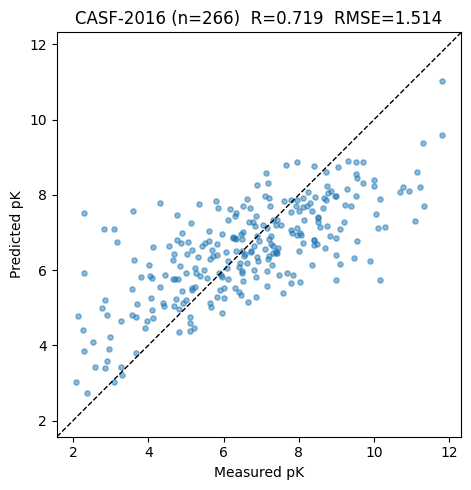

In [5]:
model = best["model"]
pred_test = model.predict(X_test)

metrics = {
    "pearson_R": float(pearsonr(y_test, pred_test).statistic),
    "spearman_R": float(spearmanr(y_test, pred_test).statistic),
    "rmse": float(np.sqrt(mean_squared_error(y_test, pred_test))),
    "mae": float(mean_absolute_error(y_test, pred_test)),
    "n_test": int(len(y_test)),
    "best_config": {
        "max_depth": int(best["max_depth"]),
        "learning_rate": float(best["learning_rate"]),
        "val_R": float(best["val_R"]),
        "n_trees": int(best["model"].best_iteration + 1),
    },
}
for k, v in metrics.items():
    print(f"{k}: {v}" if not isinstance(v, float) else f"{k}: {v:.4f}")

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_test, pred_test, alpha=0.5, s=14)
lims = [min(y_test.min(), pred_test.min()) - 0.5, max(y_test.max(), pred_test.max()) + 0.5]
ax.plot(lims, lims, "--", color="black", lw=1)
ax.set_xlabel("Measured pK")
ax.set_ylabel("Predicted pK")
ax.set_title(
    f"CASF-2016 (n={metrics['n_test']})  R={metrics['pearson_R']:.3f}  RMSE={metrics['rmse']:.3f}"
)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal")
fig.tight_layout()
fig.savefig(REPORTS / "baseline_casf2016_scatter.png", dpi=150)
plt.show()

## Save model + metrics

Saved to `runs/baseline/` for comparison with the deep model.

In [6]:
RUN_DIR = Path("../runs/baseline")
RUN_DIR.mkdir(parents=True, exist_ok=True)
model.save_model(str(RUN_DIR / "xgboost.json"))
(RUN_DIR / "metrics.json").write_text(json.dumps(metrics, indent=2))
(RUN_DIR / "grid.json").write_text(json.dumps(results, indent=2, default=float))
print(f"Saved model + metrics to {RUN_DIR.resolve()}")

Saved model + metrics to C:\Users\fearg\Protein_Ligand_Binding\runs\baseline
